# Building the PIKART atmospheric river datacube on EarthCODE

This notebook builds **`atmospheric_river_cube.zarr`** — the EarthCODE-published xcube-compliant version of the PIKART v1.1 Eulerian Atmospheric River Catalog + harmonised extreme precipitation masks. It pulls this data straight from the original PIK THREDDS source files. The output is a global, 0.5°, 6-hourly datacube spanning 1940–2023 with nine variables: atmospheric-river properties (`ar_mask`, `duration`, `intensity`, `rank`, `ivt`) and co-located (extreme) precipitation variables (`tp`, `epe_p90`, `epe_p95`, `epe_p99`).

## What this notebook does

1. **Build** the cube directly from PIK THREDDS with xcube conventions baked in from the first write. The write is performed year-by-year to comply with common RAM limitations.
2. **Safeguard** against interruptions: every year is verified for monotonicity; resume is driven by the cube's current state.
3. **Polish** the metadata in place (time units string, color hints, GCMD keyword URLs, ..).
4. **Validate** linting with xrlint (target: 0 errors, 0 warnings) and a visual sanity-check plot.

## Prerequisites

- DeepESDL JupyterLab with the `deepesdl-xcube-1.11.x` kernel (provides `xcube`, `xarray`, `zarr`, `s3fs`).
- Environment variables `S3_USER_STORAGE_KEY`, `S3_USER_STORAGE_SECRET`, `S3_USER_STORAGE_BUCKET` set for the DeepESDL bucket.
- `xrlint` installed (`pip install xrlint`).

> **Note on runtime:** a full build from THREDDS can take several hours, depending on network. The script is interruption-tolerant — re-running picks up where the cube left off. The metadata-polish and validation steps each take seconds.


## Credit & references:

The cube was built by **Tobias Braun** within the ARNETLAB project (ESA Living Planet Fellowship 2024-2026, grant no. 4000144018/24/I-DT-lr, access to DeepESDL through NoR) with the kind assisstance of **Tejas Morbagal Harish** (Brockmann Consult GmbH) and **Anca Anghelea** (European Space Agency).
**Collaborators**: Sara M. Vallejo-Bernal, Norbert Marwan, Juergen Kurths.

**Scientific references:**
- Vallejo-Bernal, S. M. & Braun, T., Marwan, N., & Kurths, J. (2025). *PIKART: A comprehensive global catalog of atmospheric rivers.* JGR Atmospheres, 130, e2024JD041869. https://doi.org/10.1029/2024JD041869
- Vallejo-Bernal, S., Braun, T., Marwan, N., & Kurths, J. (2026). *PIKART Version 1.1: Release Notes.* https://doi.org/10.31223/X5PB5Z

In [1]:
import os
import sys
import json
import numpy as np
import xarray as xr
import s3fs
import zarr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from xcube.core.store import new_data_store
import xrlint.all as xrl


def log(msg):
    """Print and flush immediately so live-tailed logs show real progress."""
    print(msg, flush=True)

## 1. Configuration

Set sources and destination.

In [2]:
# --- Source THREDDS roots (PIK) ---
# AR catalog: per-year files named PIKART_V1.1_eulerian_ERA5_0p5deg_6hr_{year}.nc
# Precip:     per-year files named tp_EPE_ERA5_0p5deg_6hr_{year}_global.nc
THREDDS_AR_ROOT     = "ar.pik-potsdam.de/thredds/fileServer/eulerian_era5"  
THREDDS_PRECIP_ROOT = "ar.pik-potsdam.de/thredds/fileServer/precipitation"

# --- Destination ---
OUTPUT_ID = "atmospheric_river_cube.zarr"
YEARS     = range(1940, 2024)

# --- I/O ---
BATCH_SIZE = 200                              # timesteps per write — bounded RAM (~10 GB/block)

# --- Chunking ---
DATA_CHUNKS       = (BATCH_SIZE, 361, 720)    # one map slab per chunk
TIME_COORD_CHUNK  = 50_000                    # 122,723 timesteps → 3 chunks

# --- Time encoding (CF UDUNITS, space-separated) ---
TIME_UNITS    = "hours since 1940-01-01 00:00:00 +00:00"
TIME_CALENDAR = "proleptic_gregorian"

# --- Variables to keep from each source ---
AR_VARS     = ["ar_mask", "duration", "intensity", "rank", "ivt"]
PRECIP_VARS = ["tp", "epe_p90", "epe_p95", "epe_p99"]

## 2. Storage and source data

S3 credentials are read from environment variables. Three stores are needed: the DeepESDL bucket (destination) and two HTTPS stores pointing at PIK's THREDDS (AR and precip sources).

In [4]:
# --- Credentials ---
S3_KEY    = os.environ["S3_USER_STORAGE_KEY"]
S3_SECRET = os.environ["S3_USER_STORAGE_SECRET"]
S3_BUCKET = os.environ["S3_USER_STORAGE_BUCKET"]

# --- DeepESDL team bucket (destination) ---
fs = s3fs.S3FileSystem(anon=False, key=S3_KEY, secret=S3_SECRET)
bucket_path    = f"s3://{S3_BUCKET}"
output_mapper  = fs.get_mapper(f"{bucket_path}/{OUTPUT_ID}")

team_store = new_data_store(
    "s3", root=S3_BUCKET,
    storage_options=dict(anon=False, key=S3_KEY, secret=S3_SECRET),
)

# --- PIK THREDDS sources ---
store_AR     = new_data_store("https", root=THREDDS_AR_ROOT)
store_precip = new_data_store("https", root=THREDDS_PRECIP_ROOT)

log(f"Destination: s3://{S3_BUCKET}/{OUTPUT_ID}")
log(f"AR source:     https://{THREDDS_AR_ROOT}")
log(f"Precip source: https://{THREDDS_PRECIP_ROOT}")

Destination: s3://hub-deepesdl53/atmospheric_river_cube.zarr
AR source:     https://ar.pik-potsdam.de/thredds/fileServer/eulerian_era5
Precip source: https://ar.pik-potsdam.de/thredds/fileServer/precipitation


## 3. Helper functions

Four helpers do the work:

- **`get_cube_state()`** — opens the destination if it exists and returns its current size, last timestamp, and whether it's monotonic. This is the single source of truth for resume logic.
- **`transform_block()`** — applies the xcube-compliance transforms (rename `latitude`/`longitude` → `lat`/`lon`, add `spatial_ref` grid mapping, tag data variables) to a year's loaded block.
- **`build_first_write_encoding()`** — returns an explicit `encoding=` dict for the very first `to_zarr(mode="w")` call, locking in CF-compliant time units, chunk sizes, and absence of `_FillValue` on coordinates.
- **`load_and_merge_year()`** — opens the AR and precipitation files for one year from THREDDS, aligns their grids, restricts to common timestamps, and returns the merged dataset.

In [5]:
def get_cube_state():
    """Return (exists, last_timestamp_or_None, is_monotonic, n_timesteps)."""
    items = [x.rstrip("/").split("/")[-1] for x in fs.ls(bucket_path)]
    if OUTPUT_ID not in items:
        return False, None, True, 0
    try:
        ds = xr.open_zarr(output_mapper, consolidated=True)
        t = ds.time.values
        n = len(t)
        if n == 0:
            ds.close()
            return True, None, True, 0
        last = np.datetime64(t[-1])
        monotonic = bool((np.diff(t).astype("timedelta64[s]").astype(np.int64) > 0).all()) if n > 1 else True
        ds.close()
        return True, last, monotonic, n
    except Exception as e:
        log(f"⚠ Cube exists but cannot be opened: {e}")
        return True, None, False, 0


def transform_block(ds_block):
    """Apply xcube-compliance transforms to one in-memory block."""
    ds_block = ds_block.rename({"latitude": "lat", "longitude": "lon"})
    ds_block = ds_block.assign_coords(
        spatial_ref=xr.DataArray(0, attrs={
            "grid_mapping_name": "latitude_longitude",
            "longitude_of_prime_meridian": 0.0,
            "semi_major_axis": 6378137.0,
            "inverse_flattening": 298.257223563,
            "crs_wkt": (
                'GEOGCS["WGS 84",DATUM["WGS_1984",'
                'SPHEROID["WGS 84",6378137,298.257223563]],'
                'PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]]'
            ),
            "spatial_ref": "EPSG:4326",
        })
    )
    for v in ds_block.data_vars:
        ds_block[v].attrs["grid_mapping"] = "spatial_ref"
    return ds_block


def build_first_write_encoding(ds_block):
    """Explicit encoding dict for the FIRST to_zarr() call. Locks in time format,
    chunk sizes, and removes _FillValue from coordinates."""
    enc = {
        "time":        {"units": TIME_UNITS, "calendar": TIME_CALENDAR,
                        "chunks": (TIME_COORD_CHUNK,), "dtype": "int64", "_FillValue": None},
        "lat":         {"chunks": (361,), "dtype": "float32", "_FillValue": None},
        "lon":         {"chunks": (720,), "dtype": "float32", "_FillValue": None},
        "spatial_ref": {"dtype": "int64", "_FillValue": None},
    }
    for v in ds_block.data_vars:
        enc[v] = {"chunks": DATA_CHUNKS, "dtype": ds_block[v].dtype.name}
    return enc


def load_and_merge_year(year):
    """Open AR + precipitation files for a single year from THREDDS,
    align grids, restrict to common timestamps, return merged dataset."""
    ar = store_AR.open_data(
        f"PIKART_V1.1_eulerian_ERA5_0p5deg_6hr_{year}.nc", chunks={}
    )[AR_VARS]
    pr = store_precip.open_data(
        f"tp_EPE_ERA5_0p5deg_6hr_{year}_global.nc", chunks={}
    )[PRECIP_VARS]

    # Align latitude (some PIKART files have inverted-sign or shifted grids)
    if not ar.latitude.identical(pr.latitude):
        pr = pr.interp(latitude=ar.latitude)

    # Common timestamps only
    common = np.intersect1d(ar.time.values, pr.time.values)
    if len(common) == 0:
        return None
    ar = ar.sel(time=common)
    pr = pr.sel(time=common)

    # Align longitude (in case of staggered grids)
    if not ar.longitude.identical(pr.longitude):
        pr = pr.interp(longitude=ar.longitude)

    return xr.merge([ar, pr])

## 4. Pre-flight: resume from cube state

If the destination cube already exists, find its last timestamp and resume from there. If it doesn't exist, this is a fresh build. You'd want to make sure that is_first_write is set accordingly!

In [6]:
exists, last_in_cube, monotonic, n_in_cube = get_cube_state()

if exists and not monotonic:
    raise RuntimeError(
        "Destination cube exists but is NOT monotonic. "
        "Refusing to append. Delete the cube manually and re-run, or investigate."
    )

if exists and n_in_cube > 0:
    log(f"Resume: {n_in_cube:,} timesteps already present, last = {last_in_cube}")
    log(f"        Will write timestamps strictly after {last_in_cube}")
    is_first_write = False
else:
    log("Fresh build: destination empty or absent")
    is_first_write = True
    last_in_cube   = None

Resume: 122,723 timesteps already present, last = 2023-12-31T21:00:00.000000000
        Will write timestamps strictly after 2023-12-31T21:00:00.000000000


## 5. Main build loop

For each year:

1. Load and merge the AR + precipitation files from THREDDS.
2. Filter out any timestamps already in the destination cube (uniqueness of time steps).
3. Apply the xcube transforms.
4. Write in `BATCH_SIZE`-timestep blocks (`.load()` each block to bound RAM at ~10 GB).
5. After the year completes, verify the cube is still monotonic — abort immediately if not.

The first block of the very first year is written with `mode="w"` and an explicit encoding dict; subsequent blocks use `mode="a", append_dim="time"`.

In [ ]:
n_written = 0

for year in YEARS:
    log(f"\n=== Year {year} ===")

    merged = load_and_merge_year(year)
    if merged is None:
        log(f"  No overlapping timestamps for {year}, skipping")
        continue

    # Filter against actual cube state
    if last_in_cube is not None:
        mask = merged.time.values > last_in_cube
        n_skip = int((~mask).sum())
        if n_skip:
            log(f"  Skipping {n_skip} timestamps already in cube")
        merged = merged.isel(time=mask)
        if merged.sizes["time"] == 0:
            log(f"  Nothing new to write for {year}")
            continue

    nt = merged.sizes["time"]
    log(f"  Writing {nt} timesteps in batches of {BATCH_SIZE}")

    for t0 in range(0, nt, BATCH_SIZE):
        t1       = min(t0 + BATCH_SIZE, nt)
        ds_block = merged.isel(time=slice(t0, t1)).load()
        ds_block = transform_block(ds_block)

        if is_first_write:
            ds_block.to_zarr(
                output_mapper, mode="w", consolidated=True,
                encoding=build_first_write_encoding(ds_block),
            )
            is_first_write = False
        else:
            block_to_append = ds_block.drop_vars("spatial_ref")
            for v in block_to_append.data_vars:
                block_to_append[v].attrs.clear()    # avoid append-time attr conflicts
            block_to_append.to_zarr(
                output_mapper, mode="a", append_dim="time", consolidated=True
            )

        last_in_cube = np.datetime64(ds_block.time.values[-1])
        n_written  += (t1 - t0)
        log(f"    [{t0:5d}:{t1:5d}] last={last_in_cube}, total_this_run={n_written:,}")

    # Monotonicity check after each year — fail loud, fail early
    _, _, monotonic_v, n_v = get_cube_state()
    if not monotonic_v:
        raise RuntimeError(
            f"Cube is NOT monotonic after writing year {year}. "
            "Stopping. Inspect the cube and check for duplicates."
        )
    log(f"  ✓ Year {year} done — cube now has {n_v:,} timesteps, monotonic")

log("\nBuild complete.")

## 6. Post-build metadata polish (in-place, no rewrite)

The bulk data is in place. What's left is metadata: small JSON edits to the Zarr's `.zattrs` files, then a single `consolidate_metadata()` call to refresh `.zmetadata`. This only takes seconds.

### 6a. CF-compliant time units string

xarray's CF encoder re-serializes our explicit `"hours since 1940-01-01 00:00:00 +00:00"` as ISO-8601 (`...T00:00:00+00:00`) during the write. The CF standard accepts both, but xrlint enforces the space-separated UDUNITS form strictly. We overwrite the attribute directly to comply...

In [ ]:
# Fix time units in the array's .zattrs
attrs_key = f"{S3_BUCKET}/{OUTPUT_ID}/time/.zattrs"
with fs.open(attrs_key, "r") as f:
    attrs = json.load(f)

attrs["units"]    = TIME_UNITS
attrs["calendar"] = TIME_CALENDAR

with fs.open(attrs_key, "w") as f:
    json.dump(attrs, f, indent=2)

zarr.consolidate_metadata(output_mapper)
log(f"✓ Time units set to {TIME_UNITS!r}")

### 6b. Color hints for the xcube Viewer

xcube/EarthCODE renderers use `color_bar_name`, `color_value_min`, `color_value_max` to pick sensible default styling. Ranges below are *visual stretch* ranges (~5th–99th percentile, not data extrema).

In [ ]:
group = zarr.open_group(output_mapper, mode="r+")

color_hints = {
    "ar_mask":   {"color_value_min": 0,   "color_value_max": 1,    "color_bar_name": "Greys"},
    "duration":  {"color_value_min": 0,   "color_value_max": 200,  "color_bar_name": "plasma"},
    "intensity": {"color_value_min": 0,   "color_value_max": 1500, "color_bar_name": "magma"},
    "rank":      {"color_value_min": 1,   "color_value_max": 5,    "color_bar_name": "Spectral"},
    "ivt":       {"color_value_min": 0,   "color_value_max": 1000, "color_bar_name": "viridis"},
    "tp":        {"color_value_min": 0,   "color_value_max": 0.05, "color_bar_name": "Blues"},
    "epe_p90":   {"color_value_min": 0,   "color_value_max": 1,    "color_bar_name": "Reds"},
    "epe_p95":   {"color_value_min": 0,   "color_value_max": 1,    "color_bar_name": "Reds"},
    "epe_p99":   {"color_value_min": 0,   "color_value_max": 1,    "color_bar_name": "Reds"},
}

for var, hints in color_hints.items():
    for k, v in hints.items():
        group[var].attrs[k] = v

zarr.consolidate_metadata(output_mapper)
log(f"✓ Color hints applied to {len(color_hints)} variables")

### 6c. GCMD keyword URLs and ACDD discovery metadata

`gcmd_keyword_url` attributes point at the canonical GCMD Keyword Viewer entries (per ESA preference). ACDD attributes (`title`, `summary`, `creator_*`, geospatial/temporal bounds) make the cube discoverable to standard EO catalogs.

In [ ]:
group = zarr.open_group(output_mapper, mode="r+")

# --- GCMD keyword URLs per variable (replace placeholders with real URLs from GCMD Viewer) ---
gcmd_urls = {
    "ar_mask":   ["31ca2413-f257-4ceb-849a-68538efecfee"],
    "intensity": ["425486f4-7b04-4b77-af40-563fe6ed4167"],
    "rank":      ["b7d562cf-9b9b-4461-900b-50423a8c4d29"],
    "ivt":       ["425486f4-7b04-4b77-af40-563fe6ed4167"],
    "tp":        ["039bbfd2-7653-4ba8-9003-b46d367c6038"],
    "epe_p90":   ["fc5a1b7a-5ee8-4d67-80f5-a57e3f1734ab"],
    "epe_p95":   ["fc5a1b7a-5ee8-4d67-80f5-a57e3f1734ab"],
    "epe_p99":   ["fc5a1b7a-5ee8-4d67-80f5-a57e3f1734ab"],
}

for v, urls in gcmd_urls.items():
    group[v].attrs["gcmd_keyword_url"] = ", ".join(urls)

# --- ACDD-recommended discovery attributes (global) ---
group.attrs.update({
    "title": ("PIK Atmospheric River Trajectories (PIKART) Eulerian Catalog v1.1 "
              "with co-located ERA5 precipitation"),
    "summary": (
        "Global gridded catalog of atmospheric rivers (ARs) derived from ERA5 reanalysis (1940-2023) "
        "at 0.5° spatial and 6-hourly temporal resolution, with co-located ERA5 total precipitation "
        "and binary extreme-precipitation flags at the 90th, 95th, and 99th percentile thresholds "
        "(1940-2024 baseline)."
    ),
    "Conventions":          "CF-1.12, ACDD-1.3",
    "institution":          "Potsdam Institute for Climate Impact Research (PIK) and Leipzig University",
    "source":               "Atmospheric river detection tool applied to ERA5 reanalysis",
    "references":           "Vallejo-Bernal et al. (2025), JGR Atmospheres, https://doi.org/10.1029/2024JD041869",
    "creator_name":         "Tobias Braun; Sara M. Vallejo-Bernal; Norbert Marwan; Jürgen Kurths",
    "creator_institution":  "Potsdam Institute for Climate Impact Research (PIK)",
    "publisher_name":       "Potsdam Institute for Climate Impact Research (PIK)",
    "license":              "CC-BY-4.0",
    "cdm_data_type":        "Grid",
    "geospatial_lat_min":   -90.0,
    "geospatial_lat_max":    90.0,
    "geospatial_lon_min":  -180.0,
    "geospatial_lon_max":   180.0,
    "geospatial_lat_units": "degrees_north",
    "geospatial_lon_units": "degrees_east",
    "time_coverage_start":  "1940-01-01T09:00:00Z",
    "time_coverage_end":    "2023-12-31T21:00:00Z",
    "time_coverage_resolution": "PT6H",
})

zarr.consolidate_metadata(output_mapper)
log("✓ GCMD URLs + ACDD metadata applied")

## 7. Validation

### 7a. Lint with xrlint (CF + xcube rule sets)

Target: **0 errors, 0 warnings**.

In [7]:
ds = team_store.open_data(OUTPUT_ID)

linter = xrl.new_linter(
    "recommended",
    {"plugins": {"xcube": "xrlint.plugins.xcube"}},
    "xcube/recommended",
)
result = linter.validate(ds)

SEVERITY = {0: "off", 1: "WARN", 2: "ERROR"}
errors = [m for m in result.messages if m.severity == 2]
warns  = [m for m in result.messages if m.severity == 1]

print("=" * 70)
print(f"  {len(errors)} errors, {len(warns)} warnings")
print("=" * 70)
for m in errors + warns:
    print(f"\n[{SEVERITY[m.severity]:5s}] {m.rule_id}")
    print(f"        at: {m.node_path}")
    print(f"        {m.message}")

  0 errors, 0 warnings


### 7b. Visual sanity check

Six sample years spanning 1940–2023. Top row: AR frequency per cell (count of timesteps with `ar_mask == 1` in that year). Bottom row: annual total precipitation per cell. Spatial patterns should match expectations — AR activity concentrated in midlatitude storm-track regions; precipitation hotspots in monsoon, ITCZ, and AR-impacted coastal regions.

Processing 1940...
Processing 1957...
Processing 1973...
Processing 1990...
Processing 2006...
Processing 2023...


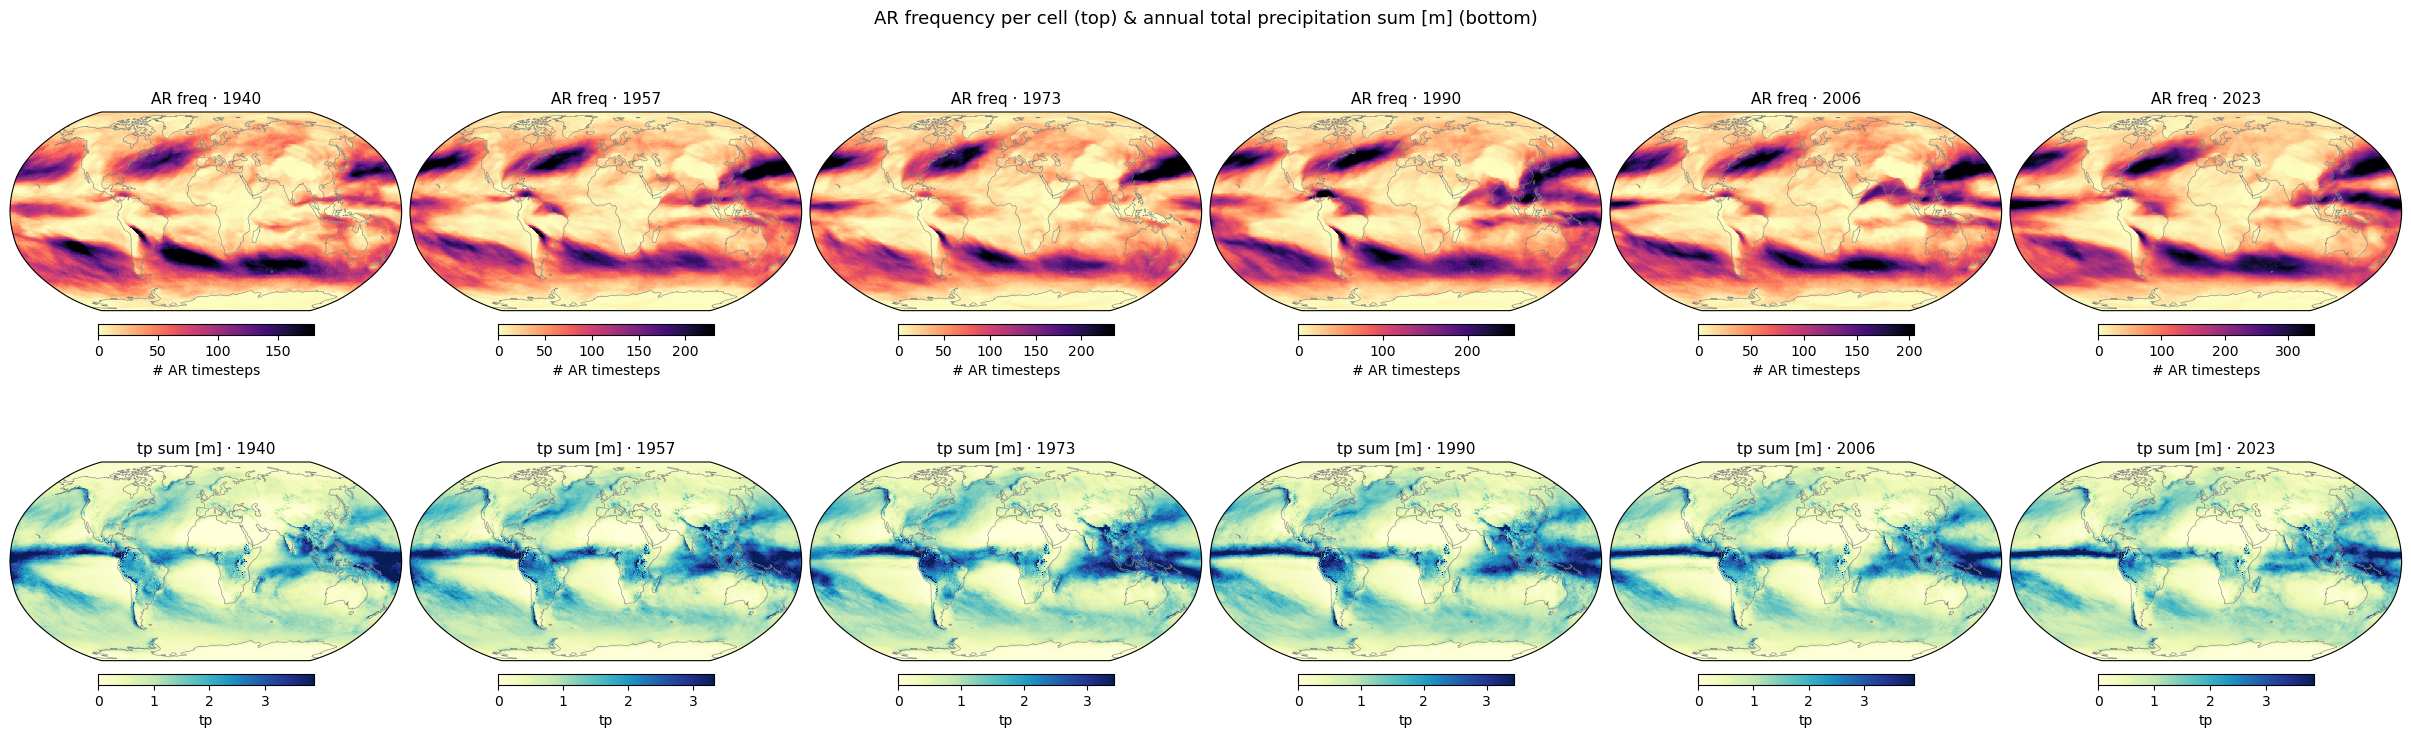

In [8]:
ARcube = ds.copy()

years_to_plot = np.linspace(1940, 2023, 6).round().astype(int)

proj = ccrs.Robinson()
fig, axes = plt.subplots(
    2, 6, figsize=(24, 7),
    subplot_kw={'projection': proj},
    constrained_layout=True,
)

for i, yr in enumerate(years_to_plot):
    print(f"Processing {yr}...", flush=True)
    ds_yr = ARcube.sel(time=str(yr))

    ar_freq   = ds_yr['ar_mask'].sum(dim='time').compute()
    tp_annual = ds_yr['tp'].sum(dim='time').compute()

    # Top row: AR frequency
    ax = axes[0, i]
    im1 = ax.pcolormesh(
        ar_freq.lon, ar_freq.lat, ar_freq.values,
        cmap='magma_r', shading='auto',
        vmin=0, vmax=np.nanpercentile(ar_freq.values, 99),
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines(linewidth=0.4, color='gray')
    ax.set_global()
    ax.set_title(f'AR freq · {yr}', fontsize=11)
    plt.colorbar(im1, ax=ax, shrink=0.55, orientation='horizontal',
                 pad=0.04, label='# AR timesteps')

    # Bottom row: annual total precipitation
    ax = axes[1, i]
    im2 = ax.pcolormesh(
        tp_annual.lon, tp_annual.lat, tp_annual.values,
        cmap='YlGnBu', shading='auto',
        vmin=0, vmax=np.nanpercentile(tp_annual.values, 99),
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines(linewidth=0.4, color='gray')
    ax.set_global()
    ax.set_title(f'tp sum [m] · {yr}', fontsize=11)
    plt.colorbar(im2, ax=ax, shrink=0.55, orientation='horizontal',
                 pad=0.04, label='tp')

fig.suptitle(
    'AR frequency per cell (top) & annual total precipitation sum [m] (bottom)',
    fontsize=13, y=1.03,
)
plt.show()